In [2]:
import numpy as np

In [3]:
#Exercício 2.1

# Soma de dois vetores da imagem 2.2

v = np.array([[1,2,0]]) #posição inicial (0,0,0) final (1,2,0)
w = np.array([[4,-6,0]]) #posição inicial (1,2,0) final (5,-4,0)
v+w

#vetor v+W deve ter: inicial (0,0,0) e fim (5,-4,0))

array([[ 5, -4,  0]])

In [4]:
#Exercício 2.2

#Algoritimo que faça a norma de um vetor qualquer

def norma(v):
    return np.sqrt(v[0] ** 2 + v[1] ** 2 + v[2] ** 2)

print(norma((w[0])))

# Função pronta: np.linalg.norm(v)

7.211102550927978


In [ ]:
#Exercício 2.3

#algoritmo para normalizar um vetor para unitário

def vetor_unit(v):
    n = norma(v)
    return v/n

print(vetor_unit([5,0,0]))
print(vetor_unit([0,0,0])) # Resulta em Nan

[1. 0. 0.]
[nan nan nan]


/tmp/ipykernel_105382/2535247658.py:7: RuntimeWarning: invalid value encountered in divide
  return v/n


In [8]:
#Exercício 2.4

#Devemos fazer com que alongamos ou encurtamos um vetor pela multiplicação de uma constante m, para fazermos isso devemos tornálo unitário e depois multiplicar por m


def vetor_magnitude_desejada(v,m):
    vetor_unitario = vetor_unit(v)
    return m*vetor_unitario

print(vetor_magnitude_desejada([5,2,1], 2))


[1.82574186 0.73029674 0.36514837]


In [87]:
#Exercício 2.5

#Criar u laço for que faz transposição de uma matriz linha para uma coluna

def transposicao(v):
    
    vet  = np.array(v)
    
    if len(vet.shape) == 1:
        vet = vet.reshape(1, -1)  # transforma em linha

    linhas , colunas = vet.shape

    n = linhas if linhas > 1 else colunas
    

    vetor_t =[]
    for i in range(n):
        if(linhas > 1 and colunas == 1):
            linha = []
            for i in range(n):
                linha.append(vet[i][0])
            vetor_t.append(linha)
            break
            
        elif(linhas == 1 and colunas >1):
            vetor_t.append([vet[0][i]])


    return np.array(vetor_t)
         
    

print(transposicao([0,1,2,3]))
print(transposicao([[0],[1],[2],[3]]))

[[0]
 [1]
 [2]
 [3]]
[[0 1 2 3]]


In [88]:
#Exercício 2.6

#Calcular o quadrado na norma

def quadrado_norma(v):
    return norma(v) ** 2

print(quadrado_norma([1,2,3]))

14.0


In [95]:
#Exercíccio 2.7

#Demonstrar que o produto escalar é comutativo, ou seja: at x b = a x bt

def comutativo_escalar(a,b):

    a = np.array(a).reshape(1, -1)   # linha
    b = np.array(b).reshape(1, -1)   # linha

    at = transposicao(a)
    bt = transposicao(b)

    res1 = a @ bt   # a @ b
    res2 = b @ at   # a @ b

    return np.allclose(res1, res2)
    
print(comutativo_escalar([1,2,3], [4,5,6]))
    

True


In [ ]:
#Exercício 2.8

#Fazer um algoritmo da projeção de um vetor

def projecao(a, b):
    a = np.array(a)
    b = np.array(b)
    
    return (np.dot(a, b) / quadrado_norma(b)) * b

print(projecao([1,2,3], [4,5,6]))

[1.66233766 2.07792208 2.49350649]


t: [1.76405235 0.40015721]
t_par: [0.42937802 0.98309282]
t_perp: [ 1.33467432 -0.58293562]

Soma (t_par + t_perp): [1.76405235 0.40015721]
Produto escalar (deve ser 0): 1.1102230246251565e-16


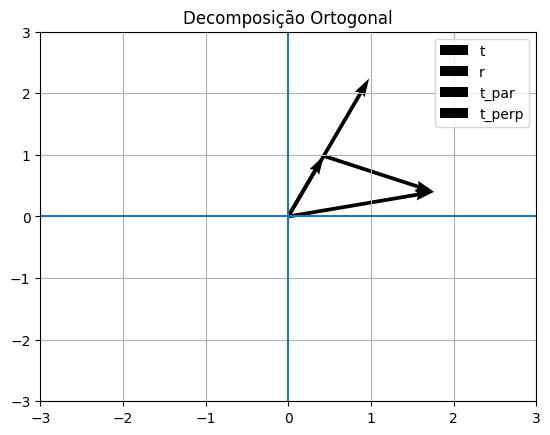

In [114]:
#Exercício 2.9

#Fazer um grafico com projeção vetorial e decomposição ortogonal

import numpy as np
import matplotlib.pyplot as plt

# Vetores aleatórios
np.random.seed(0)
t = np.random.randn(2)
r = np.random.randn(2)

# Parte paralela (projeção)
t_par = (np.dot(t, r) / np.dot(r, r)) * r

# Parte perpendicular
t_perp = t - t_par

# 🔍 Verificações
print("t:", t)
print("t_par:", t_par)
print("t_perp:", t_perp)

# Soma
print("\nSoma (t_par + t_perp):", t_par + t_perp)

# Ortogonalidade
print("Produto escalar (deve ser 0):", np.dot(t_par, t_perp))

# 📊 Gráfico
plt.quiver(0,0, t[0], t[1], angles='xy', scale_units='xy', scale=1, label='t')
plt.quiver(0,0, r[0], r[1], angles='xy', scale_units='xy', scale=1, label='r')
plt.quiver(0,0, t_par[0], t_par[1], angles='xy', scale_units='xy', scale=1, label='t_par')
plt.quiver(t_par[0], t_par[1], t_perp[0], t_perp[1],
           angles='xy', scale_units='xy', scale=1, label='t_perp')

plt.xlim(-3,3)
plt.ylim(-3,3)
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.legend()
plt.title("Decomposição Ortogonal")

plt.show()

In [116]:
#Exercício 2.10

#Fazer a projeção errada é muitas vezes comum, fazer um algoritmo que faz os dois jeitos, correto e errado da projeção, mudando o denominador da fração da formula da projeção

import numpy as np

np.random.seed(0)

t = np.random.randn(3)
r = np.random.randn(3)

# correto
t_par = (np.dot(t, r) / np.dot(r, r)) * r

# errado
t_par_bug = (np.dot(t, r) / np.dot(t, t)) * r

# partes perpendiculares
t_perp = t - t_par
t_perp_bug = t - t_par_bug

print("Correto:", t_par)
print("Errado:", t_par_bug)

Correto: [ 0.8864347   0.73875373 -0.38658381]
Errado: [ 1.98339109  1.65295601 -0.86497841]


In [ ]:
#Exercício 3.1

#Fazer um algoritmo para combinação linear

# escalares
escalares = [2, -1, 3]

# vetores
vetores = [
    np.array([1, 2, 3]),
    np.array([4, 5, 6]),
    np.array([7, 8, 9])
]

# inicializa vetor de saída
resultado = np.zeros(len(vetores[0]))

# combinação linear
for i in range(len(escalares)):
    resultado += escalares[i] * vetores[i]

print("Resultado:", resultado)

#Código mais simples sem as restrições dadas
resultado_direto = (
    escalares[0]*vetores[0] +
    escalares[1]*vetores[1] +
    escalares[2]*vetores[2]
)

print("Direto:", resultado_direto)

Resultado: [19. 23. 27.]
Direto: [19 23 27]


In [120]:
#Exercícios 3.2

#Analisar as dimensões e os escalares: ambos tem que ter a mesma dimenção? Sim!

vetores.append(np.array([1,2,3,4]))  # dimensão diferente

#A célula de código anterior faz apenas com 3 dimensões, ao colocar uma quarta va dar erro:  operands could not be broadcast together

# Uma forma segura de confrir se a dimensão dos vetores estao padronizadas é: 

    #if len(escalares) != len(vetores):
    #raise ValueError("Número de escalares e vetores deve ser igual")

#A mesma coisa ocorre quando tem mais escalares: IndexError: list index out of range